Notebook Tasks:


1.   Data Loading and Preprocessing: Loaded the logistics data and descriptions, and preprocessed the data_df by converting date columns and encoding categorical features.
2.   Model Training: Trained a Random Forest Classifier to predict shipping delays.
3.  Evaluated the model using a confusion matrix, classification report, and cross-validation, obtaining a mean cross-validation accuracy of approximately 57.24%.
4. Impact of Shipping Mode: Visualized how different shipping modes affect delivery status.
5. Profit Correlation: Analyzed the average profit per order across different delay statuses.
6. Feature Importance: Identified and visualized the top 20 most important features influencing delay predictions.
7. Prediction Demonstration: Demonstrated how to use the trained model to predict delays for new, unseen data, including the necessary preprocessing steps.




In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
pushpitkamboj_logistics_data_containing_real_world_data_path = kagglehub.dataset_download('pushpitkamboj/logistics-data-containing-real-world-data')

print('Data source import complete.')


100%|██████████| 1.71M/1.71M [00:00<00:00, 102MB/s]

Extracting files...
Data source import complete.


In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

print(f"Dataset downloaded to: {pushpitkamboj_logistics_data_containing_real_world_data_path}")

print("Files in /kaggle/input:")
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

print(f"\nFiles in downloaded dataset directory ({pushpitkamboj_logistics_data_containing_real_world_data_path}):")
for dirname, _, filenames in os.walk(pushpitkamboj_logistics_data_containing_real_world_data_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Dataset downloaded to: /root/.cache/kagglehub/datasets/pushpitkamboj/logistics-data-containing-real-world-data/versions/1
Files in /kaggle/input:

Files in downloaded dataset directory (/root/.cache/kagglehub/datasets/pushpitkamboj/logistics-data-containing-real-world-data/versions/1):
/root/.cache/kagglehub/datasets/pushpitkamboj/logistics-data-containing-real-world-data/versions/1/incom2024_delay_example_dataset.csv
/root/.cache/kagglehub/datasets/pushpitkamboj/logistics-data-containing-real-world-data/versions/1/incom2024_delay_variable_description.csv


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
data_df = pd.read_csv(os.path.join(pushpitkamboj_logistics_data_containing_real_world_data_path, 'incom2024_delay_example_dataset.csv'))
display(data_df.head())

,payment_type,profit_per_order,sales_per_customer,category_id,category_name,customer_city,customer_country,customer_id,customer_segment,customer_state,...,order_region,order_state,order_status,product_card_id,product_category_id,product_name,product_price,shipping_date,shipping_mode,label
0,DEBIT,34.448338,92.49099,9.0,Cardio Equipment,Caguas,Puerto Rico,12097.6830,Consumer,PR,...,Western Europe,Vienna,COMPLETE,191.0,9.0,Nike Men's Free 5.0+ Running Shoe,99.99,2015-08-13 00:00:00+01:00,Standard Class,-1
1,TRANSFER,91.193540,181.99008,48.0,Water Sports,Albuquerque,EE. UU.,5108.1045,Consumer,CA,...,South America,Buenos Aires,PENDING,1073.0,48.0,Pelican Sunstream 100 Kayak,199.99,2017-04-09 00:00:00+01:00,Standard Class,-1
2,DEBIT,8.313806,89.96643,46.0,Indoor/Outdoor Games,Amarillo,Puerto Rico,4293.4478,Consumer,PR,...,Western Europe,Nord-Pas-de-Calais-Picardy,COMPLETE,1014.0,46.0,O'Brien Men's Neoprene Life Vest,49.98,2015-03-18 00:00:00+00:00,Second Class,1
3,TRANSFER,-89.463196,99.15065,17.0,Cleats,Caguas,Puerto Rico,546.5306,Consumer,PR,...,Central America,Santa Ana,PROCESSING,365.0,17.0,Perfect Fitness Perfect Rip Deck,59.99,2017-03-18 00:00:00+00:00,Second Class,0
4,DEBIT,44.722590,170.97824,48.0,Water Sports,Peabody,EE. UU.,1546.3980,Consumer,CA,...,Central America,Illinois,COMPLETE,1073.0,48.0,Pelican Sunstream 100 Kayak,199.99,2015-03-30 00:00:00+01:00,Standard Class,1


In [5]:
description_df = pd.read_csv(os.path.join(pushpitkamboj_logistics_data_containing_real_world_data_path, 'incom2024_delay_variable_description.csv'))
display(description_df.head())

,variable_name,type,description
0,payment_type,categorical,Type of transaction made
1,profit_per_order,numerical,Earnings per order placed
2,sales_per_customer,numerical,Total sales per customer made per customer
3,category_id,numerical,Product category code
4,category_name,text,Description of the product category


In [6]:
data_df['order_date'] = pd.to_datetime(data_df['order_date'])
data_df['shipping_date'] = pd.to_datetime(data_df['shipping_date'])

/tmp/ipykernel_14467/3920691996.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  data_df['order_date'] = pd.to_datetime(data_df['order_date'])
/tmp/ipykernel_14467/3920691996.py:2: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  data_df['shipping_date'] = pd.to_datetime(data_df['shipping_date'])


In [7]:
data_df.describe()

,profit_per_order,sales_per_customer,category_id,customer_id,customer_zipcode,department_id,latitude,longitude,order_customer_id,order_id,...,order_item_product_price,order_item_profit_ratio,order_item_quantity,sales,order_item_total_amount,order_profit_per_order,product_card_id,product_category_id,product_price,label
count,15549.000000,15549.000000,15549.000000,15549.000000,15549.000000,15549.000000,15549.000000,15549.000000,15549.000000,15549.000000,...,15549.000000,15549.000000,15549.000000,15549.000000,15549.000000,15549.000000,15549.000000,15549.000000,15549.000000,15549.000000
mean,22.604542,179.888256,31.461342,6583.279789,35458.234968,5.413462,29.677619,-84.512318,6586.810354,35718.970019,...,137.005272,0.120391,2.165202,200.562289,179.780850,22.273342,685.213286,31.387606,136.629368,0.349283
std,99.265198,113.727323,15.303616,4114.273782,37343.702033,1.581550,9.877876,20.681015,4101.324290,21071.742668,...,134.545269,0.474088,1.468627,125.984986,110.999735,117.503163,330.778230,15.256620,133.366285,0.826623
min,-3442.500000,8.351162,2.000000,1.000000,603.000000,2.000000,-33.937553,-158.025990,1.000000,1.000000,...,9.990000,-2.750000,1.000000,9.990000,7.490000,-3442.500000,19.000000,2.000000,9.990000,-1.000000
25%,7.562795,104.397330,18.000000,3119.983200,725.000000,4.000000,18.263327,-98.088170,3177.568800,16530.752000,...,50.000000,0.080000,1.000000,119.980000,105.570910,7.443977,403.000000,18.000000,50.000000,0.000000
50%,31.693370,165.944170,29.000000,6429.229000,19145.775000,5.000000,33.435677,-76.580800,6308.530000,35391.336000,...,59.990000,0.270000,1.000000,199.920000,165.990000,32.440100,627.000000,29.000000,59.990000,1.000000
75%,63.872166,242.440930,45.000000,9642.381000,77502.820000,7.000000,39.277313,-66.370575,9703.070000,55236.910000,...,199.990000,0.360000,3.000000,299.950000,242.436400,64.303566,1004.000000,45.000000,199.990000,1.000000
max,911.800000,1939.990000,76.000000,20757.000000,99205.000000,12.000000,48.781933,115.263080,20757.000000,77204.000000,...,1999.990000,0.500000,5.000000,1999.990000,1939.990000,911.800000,1363.000000,76.000000,1999.990000,1.000000


In [10]:
# Define features and target variable
X = data_df.drop(columns=['label', 'order_date', 'shipping_date'])
y = data_df['label']

# Convert categorical variables to dummy variables
X = pd.get_dummies(X, drop_first=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.5811361200428724

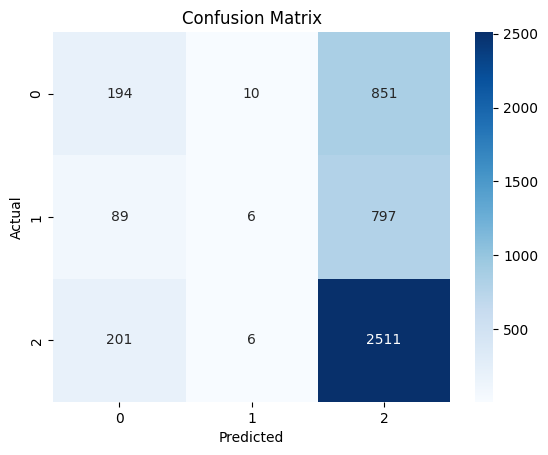

              precision    recall  f1-score   support

          -1       0.40      0.18      0.25      1055
           0       0.27      0.01      0.01       892
           1       0.60      0.92      0.73      2718

    accuracy                           0.58      4665
   macro avg       0.43      0.37      0.33      4665
weighted avg       0.49      0.58      0.49      4665



In [11]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification report
class_report = classification_report(y_test, y_pred)
print(class_report)

### Cross-Validation for Model Evaluation

In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Initialize StratifiedKFold for cross-validation to handle potential class imbalance
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
cv_scores = cross_val_score(clf, X, y, cv=kf, scoring='accuracy')

print(f"Cross-validation scores: {cv_scores}")
print(f"Mean cross-validation accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation of cross-validation accuracy: {cv_scores.std():.4f}")

Cross-validation scores: [0.56881029 0.57909968 0.56463023 0.56977492 0.57992924]
Mean cross-validation accuracy: 0.5724
Standard deviation of cross-validation accuracy: 0.0060


### Impact of Shipping Mode on Delays

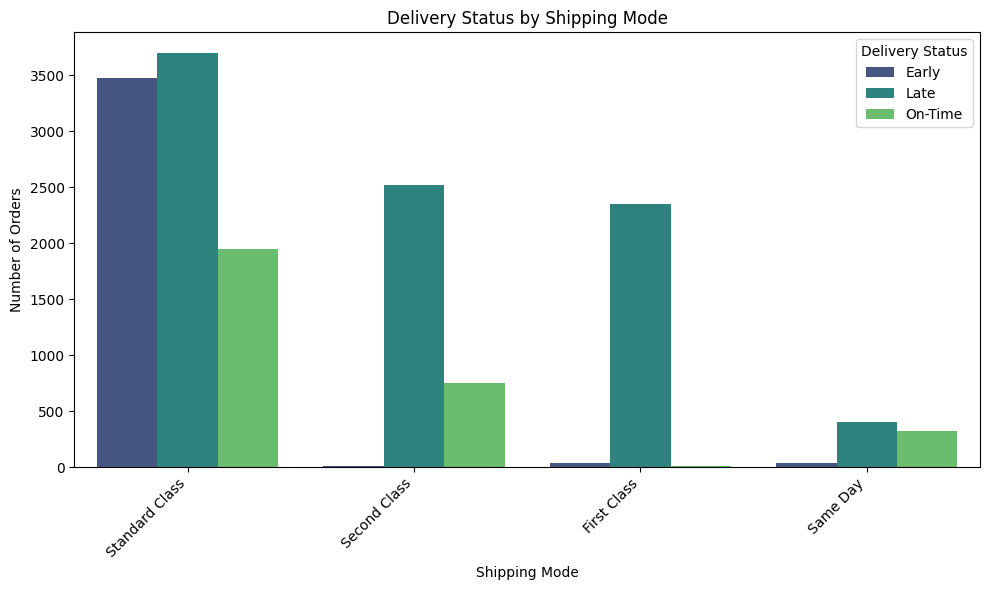

In [12]:
# Map numerical labels to descriptive strings for better readability
data_df['label_description'] = data_df['label'].map({-1: 'Early', 0: 'On-Time', 1: 'Late'})

# Create a count plot to visualize the impact of shipping mode on delays
plt.figure(figsize=(10, 6))
sns.countplot(data=data_df, x='shipping_mode', hue='label_description', palette='viridis')
plt.title('Delivery Status by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Number of Orders')
plt.legend(title='Delivery Status')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Correlation between Profit and Shipping Delays

/tmp/ipykernel_14467/2291253856.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=profit_delay_correlation, x='label_description', y='profit_per_order', palette='coolwarm')


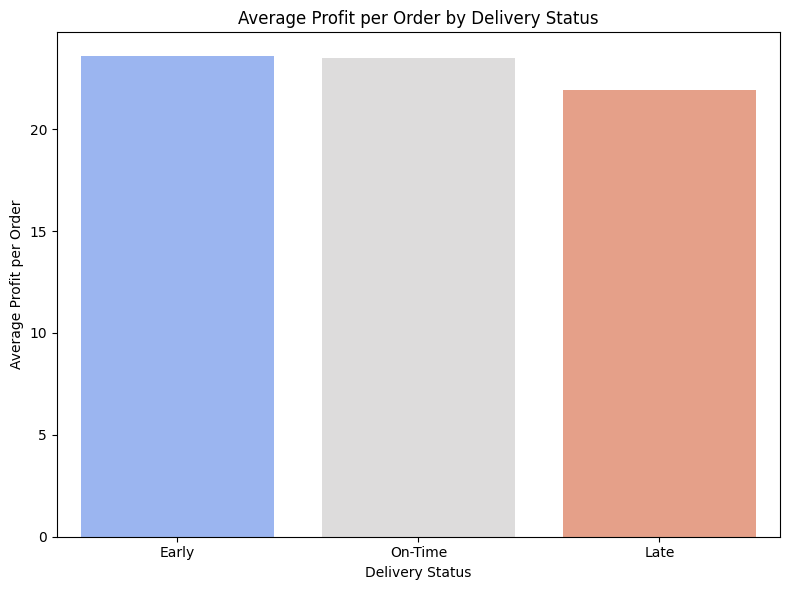

In [13]:
# Calculate the average profit per order for each delay category
profit_delay_correlation = data_df.groupby('label_description')['profit_per_order'].mean().reset_index()

# Order the categories for better visualization
order = ['Early', 'On-Time', 'Late']
profit_delay_correlation['label_description'] = pd.Categorical(profit_delay_correlation['label_description'], categories=order, ordered=True)
profit_delay_correlation = profit_delay_correlation.sort_values('label_description')

# Create a bar plot to visualize the correlation
plt.figure(figsize=(8, 6))
sns.barplot(data=profit_delay_correlation, x='label_description', y='profit_per_order', palette='coolwarm')
plt.title('Average Profit per Order by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Average Profit per Order')
plt.tight_layout()
plt.show()

### Feature Importance of Random Forest Model

Top 20 Feature Importances:


,Feature,Importance
4703,shipping_mode_Standard Class,0.075913
3,customer_id,0.023490
13,order_item_id,0.023327
9,order_id,0.023096
8,order_customer_id,0.023041
0,profit_per_order,0.023030
19,order_profit_per_order,0.022984
6,latitude,0.022885
1,sales_per_customer,0.022432
18,order_item_total_amount,0.022145


/tmp/ipykernel_14467/3025516641.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='magma')


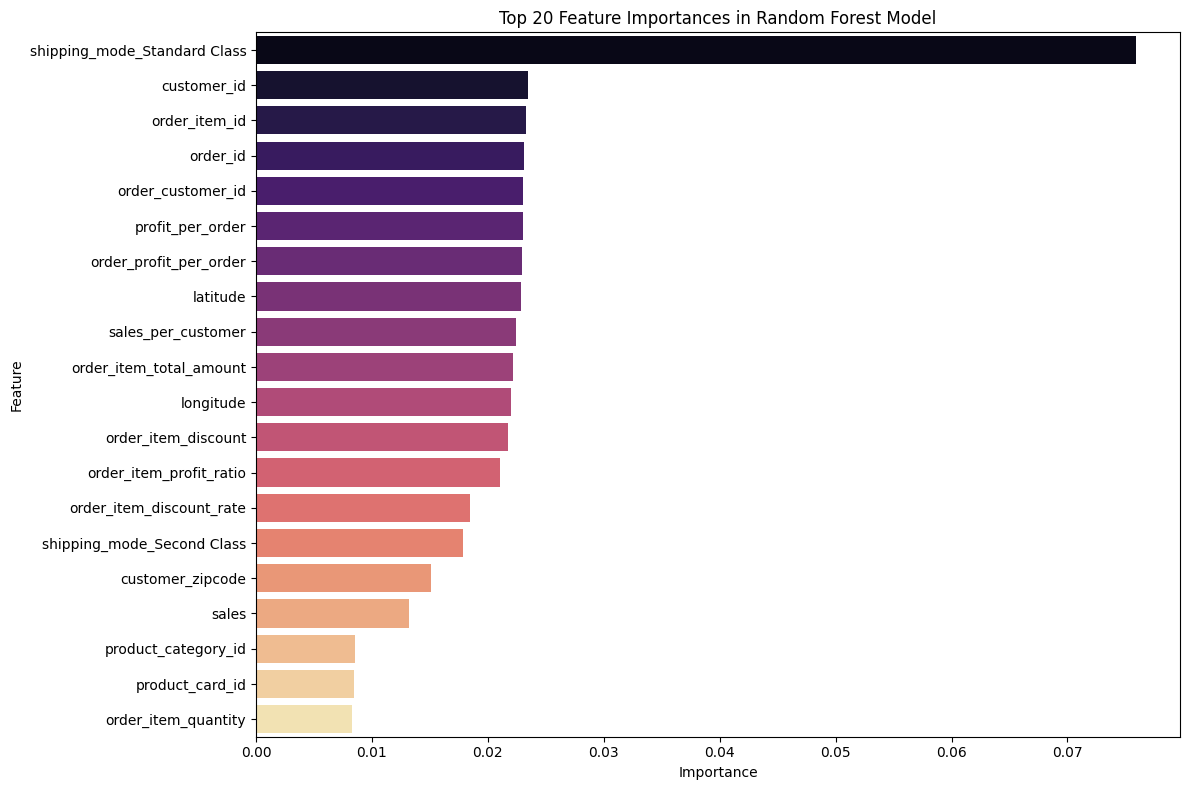

In [14]:
# Get feature importances
feature_importances = clf.feature_importances_

# Get feature names from the training data (X_train.columns as X was already processed)
feature_names = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort the DataFrame by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the top 20 most important features
print("Top 20 Feature Importances:")
display(importance_df.head(20))

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='magma')
plt.title('Top 20 Feature Importances in Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Predicting Delays with the Trained Model

In [16]:
# Assuming you have new, unseen data, let's create a sample DataFrame for demonstration.
# In a real scenario, this would be your actual new data that you want to predict delays for.
# Make sure the columns and their types are consistent with the training data (data_df).

# We'll use a slice of the original data for demonstration, but imagine this is new data.
sample_new_data = data_df.sample(5, random_state=100).copy()

# Display the sample data
print("Sample New Data for Prediction:")
display(sample_new_data)

Sample New Data for Prediction:


,payment_type,profit_per_order,sales_per_customer,category_id,category_name,customer_city,customer_country,customer_id,customer_segment,customer_state,...,order_state,order_status,product_card_id,product_category_id,product_name,product_price,shipping_date,shipping_mode,label,label_description
14144,DEBIT,11.977986,116.99000,18.0,Men's Footwear,Brooklyn,EE. UU.,11584.270,Consumer,NY,...,Provence-Alpes-Côte d'Azur,COMPLETE,403.0,18.0,Nike Men's CJ Elite 2 TD Football Cleat,129.99,2017-07-08 00:00:00+01:00,Same Day,1,Late
12893,CASH,98.333810,224.97080,17.0,Cleats,Caguas,Puerto Rico,10400.723,Consumer,PR,...,Shkoder,CLOSED,365.0,17.0,Perfect Fitness Perfect Rip Deck,59.99,2016-01-13 00:00:00+00:00,Standard Class,-1,Early
5385,PAYMENT,147.613220,453.91040,9.0,Cardio Equipment,Austin,EE. UU.,8818.892,Corporate,IL,...,Queensland,PENDING_PAYMENT,191.0,9.0,Nike Men's Free 5.0+ Running Shoe,99.99,2016-02-25 00:00:00+00:00,Standard Class,1,Late
13315,DEBIT,-2.690530,124.79000,24.0,Women's Apparel,Caguas,Puerto Rico,2415.985,Consumer,PR,...,Nord-Pas-de-Calais-Picardy,COMPLETE,502.0,24.0,Nike Men's Dri-FIT Victory Golf Polo,50.00,2015-08-09 00:00:00+01:00,Standard Class,1,Late
10704,TRANSFER,-72.247040,167.99248,48.0,Water Sports,Caguas,Puerto Rico,6488.984,Consumer,PR,...,Provence-Alpes-Côte d'Azur,PENDING,1073.0,48.0,Pelican Sunstream 100 Kayak,199.99,2017-09-01 00:00:00+01:00,Standard Class,-1,Early


In [17]:
# Preprocess the new data similarly to how the training data was processed.
# Drop the 'label', 'order_date', and 'shipping_date' columns as they were dropped during training.
# Convert categorical variables to dummy variables using pd.get_dummies.

# Ensure all columns from the original training set (X) are present in the new data
# This step is crucial to avoid dimension mismatch errors in prediction.

# Store the original training columns for later use
original_training_columns = X.columns

# Drop irrelevant columns for prediction
X_new_raw = sample_new_data.drop(columns=['label', 'order_date', 'shipping_date', 'label_description'], errors='ignore')

# Convert categorical variables to dummy variables
X_new_processed = pd.get_dummies(X_new_raw, drop_first=True)

# Reindex X_new_processed to match the columns of the original training data (X)
# Fill new columns with 0 if they were not present in the new data but were in training data.
# Drop columns from new data that were not in training data.
X_new_aligned = X_new_processed.reindex(columns=original_training_columns, fill_value=0)

print("Processed and Aligned New Data for Prediction:")
display(X_new_aligned.head())

Processed and Aligned New Data for Prediction:


,profit_per_order,sales_per_customer,category_id,customer_id,customer_zipcode,department_id,latitude,longitude,order_customer_id,order_id,...,product_name_Yakima DoubleDown Ace Hitch Mount 4-Bike Rack,product_name_adidas Brazuca 2014 Official Match Ball,product_name_adidas Kids' F5 Messi FG Soccer Cleat,product_name_adidas Men's F10 Messi TRX FG Soccer Cleat,product_name_adidas Men's Germany Black Crest Away Tee,product_name_adidas Youth Germany Black/Red Away Match Soc,product_name_insta-bed Neverflat Air Mattress,shipping_mode_Same Day,shipping_mode_Second Class,shipping_mode_Standard Class
14144,11.977986,116.99000,18.0,11584.270,10469.291,4.0,40.730835,-73.944910,11560.3190,64493.450,...,0,0,0,0,0,0,0,0,0,False
12893,98.333810,224.97080,17.0,10400.723,725.000,4.0,18.231184,-66.370560,10492.1455,44295.734,...,0,0,0,0,0,0,0,0,0,True
5385,147.613220,453.91040,9.0,8818.892,60055.316,3.0,40.675907,-95.425910,8680.6430,26526.701,...,0,0,0,0,0,0,0,0,0,True
13315,-2.690530,124.79000,24.0,2415.985,725.000,5.0,18.242727,-66.370530,2519.4578,13916.201,...,0,0,0,0,0,0,0,0,0,True
10704,-72.247040,167.99248,48.0,6488.984,725.000,7.0,18.224089,-66.370544,6472.9870,66486.450,...,0,0,0,0,0,0,0,0,0,True


In [18]:
# Make predictions using the trained model
new_predictions = clf.predict(X_new_aligned)

# Map numerical predictions back to descriptive labels for better understanding
prediction_map = {-1: 'Early', 0: 'On-Time', 1: 'Late'}
predicted_labels = [prediction_map[p] for p in new_predictions]

print("Predicted Delays for the Sample New Data:")
for i, pred in enumerate(predicted_labels):
    print(f"Sample {i+1}: Predicted Status = {pred}")

Predicted Delays for the Sample New Data:
Sample 1: Predicted Status = Late
Sample 2: Predicted Status = Early
Sample 3: Predicted Status = Late
Sample 4: Predicted Status = Late
Sample 5: Predicted Status = Early
